# Predicting Motor Skill Classification from Interpersonal Coordination Dynamics

This notebook develops a binary classifier to distinguish children with **Typical Motor Skills (TMS)** from those with **Lower Motor Skills (LMS)** based on interpersonal coordination dynamics during rhythmic tapping tasks.

### Overview

1. **Data Preparation**: Load participant data and define binary classification target (Green = TMS vs. Amber/Red = LMS)
2. **Model Training**: L2-regularised logistic regression with Leave-One-Out cross-validation (LOO-CV) for unbiased performance estimation on small samples
3. **Performance Evaluation**: ROC curves with bootstrapped confidence intervals, accuracy metrics, and confusion matrices
4. **Feature Importance**: Coefficient analysis to identify which coordination features (participant–metronome vs. participant–experimenter coupling) predict motor skill classification
5. **Error Analysis**: Detailed examination of false negatives (missed at-risk children) and false positives to understand model limitations

In [69]:
# Import necessary libraries
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    confusion_matrix, classification_report, 
    roc_curve, auc
)

In [79]:
# Load data
df = pd.read_csv("C:\\Users\\Cathy\\OneDrive - Macquarie University\\Matthew PhD (2024-)\\Study 2 Results\\Participant_Data_ML.csv")

# Define target (binary): TMS (Green) vs LMS (Amber/Red)
df = df.copy()

df["mabc_binary"] = df["mabc_interpretation"].map({
    "Green": 0,
    "Amber": 1,
    "Red": 1
})

# Sanity check class counts
print("Class counts (0=Green, 1=Amber/Red):")
print(df["mabc_binary"].value_counts(dropna=False))

# Remove ppt_exp trials where exp_met coordination was below 0.8
apply_exp_met_qc = False
exp_met_threshold = 0.8

if apply_exp_met_qc:
    # Find all Exp_Met columns that look like B#_T#_Exp_Met
    exp_met_cols = [
        c for c in df.columns
        if re.match(r"^B\d+_T\d+_Exp_Met$", c)
    ]

    removed_pairs = []  # for logging

    for exp_col in exp_met_cols:
        # Corresponding Ppt_Exp column for the same block/trial
        ppt_exp_col = exp_col.replace("_Exp_Met", "_Ppt_Exp")

        # Only proceed if that Ppt_Exp column exists
        if ppt_exp_col not in df.columns:
            continue

        # Identify rows where experimenter timing failed (or missing)
        fail_mask = df[exp_col].isna() | (pd.to_numeric(df[exp_col], errors="coerce") < exp_met_threshold)

        # Set the corresponding Ppt_Exp value to NaN (i.e., remove that trial)
        n_fail = int(fail_mask.sum())
        if n_fail > 0:
            df.loc[fail_mask, ppt_exp_col] = np.nan
            removed_pairs.append((exp_col, ppt_exp_col, n_fail))

    # Print summary
    print(f"\n[QC] Exp_Met thresholding enabled (threshold={exp_met_threshold}).")
    if len(removed_pairs) == 0:
        print("[QC] No Ppt_Exp trials were removed.")
    else:
        print("[QC] Removed Ppt_Exp values where corresponding Exp_Met < threshold (or missing):")
        for exp_col, ppt_exp_col, n_fail in removed_pairs:
            print(f"  - {ppt_exp_col} removed for {n_fail} rows (based on {exp_col})")

# Set up features and target

## Coordination features
### Keep only features that involve the participant (i.e., exclude experimenter–metronome coupling)
rho_cols = [
    c for c in df.columns
    if c.startswith("B")
    and "_" in c
    and not c.endswith("_Exp_Met")
]

### Optionally exclude certain blocks (where B1 = spont tapping, B2 = spont ball movements, B3 = intent tapping, B4 = intent ball moving)
# rho_cols = [
#     c for c in rho_cols
#     if not c.startswith("B1") and not c.startswith("B2")
# ]

## Demographics
df["child_gender"] = df["child_gender"].map({"Male": 0, "Female": 1})
demo_cols = ["child_age_years", "child_gender"]

## Psychometrics
psych_cols = [
    c for c in ["con_adhd_index_raw"] #"dcdq_total", "aq_total"
    if c in df.columns
] 

## Build feature list
feature_cols = rho_cols

## Sanity check
print(f"Total feature columns: {len(feature_cols)}")
print("Feature columns:", feature_cols)

Class counts (0=Green, 1=Amber/Red):
mabc_binary
0.0    83
1.0    43
NaN     2
Name: count, dtype: int64
Total feature columns: 13
Feature columns: ['B1_T2_Ppt_Met', 'B1_T3_Ppt_Exp', 'B2_T2_Ppt_Met', 'B2_T3_Ppt_Exp', 'B2_T4_Ppt_Exp', 'B3_T1_Ppt_Met', 'B3_T2_Ppt_Met', 'B3_T3_Ppt_Exp', 'B3_T4_Ppt_Exp', 'B4_T1_Ppt_Met', 'B4_T2_Ppt_Met', 'B4_T3_Ppt_Exp', 'B4_T4_Ppt_Exp']


### Logistic Regression with Leave-One-Out Cross-Validation

This section trains an L2-regularised logistic regression model using Leave-One-Out cross-validation (LOO-CV), which provides nearly unbiased performance estimates for small samples.

**Key findings:**
- Amber/Red classification is associated with relatively stronger participant–metronome coordination
- Green classification is associated with a mix of strong participant–metronome and participant–experimenter coordination

In [ ]:
# Choose model
logReg = False  # set to False to run HGBC instead

# Build model pipeline

# Logistic regression pipeline (requires complete cases, so only run if X has no NaNs)
## Currently L2-regularised (uses all features but shrinks coefficients)
if logReg:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="liblinear",     # good for small datasets
            C=1.0,                  # regularisation strength
            class_weight="balanced",# assigns weights to each observation in the training set - helpful with 2:1 imbalance
            max_iter=5000,
            random_state=42
        ))
    ])

    ## Drop rows with missing outcome or missing predictors
    model_df = df.dropna(subset=["mabc_binary"] + feature_cols).reset_index(drop=True)

    X = model_df[feature_cols].astype(float)
    y = model_df["mabc_binary"].astype(int)

    print("\nFinal N after dropping missing rows:", len(model_df))

    ## Check class balance after dropping missing data
    print("\nMABC class counts (after exclusion):")
    print(model_df["mabc_interpretation"].value_counts())

    ## Check binary class balance
    print("\nBinary MABC counts (0=Green, 1=Amber/Red):")
    print(model_df["mabc_binary"].value_counts())

# Alternative model: HistGradientBoostingClassifier (can handle missing data without imputation)
if not logReg:
    pipe = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.05,
        max_depth=3,
        max_iter=300,
        class_weight="balanced",
        random_state=42
    )

    # To retain as much data as possible, uncomment and run HGBC cell instead of logistic regression (since HGBC can handle missing data) 
    model_df = df.dropna(subset=["mabc_binary"]).reset_index(drop=True)

    X = model_df[feature_cols]   # leave NaNs in place
    y = model_df["mabc_binary"].astype(int)

# Leave-one-out cross-validated predictions
## Note: LOO is computationally expensive but gives an almost unbiased estimate of performance on small datasets.
## Used LOO over k-fold CV due to small sample size.
loo = LeaveOneOut()

# Predicted probabilities for class 1 (Amber/Red)
y_prob = cross_val_predict(pipe, X, y, cv=loo, method="predict_proba")[:, 1]

# Convert to class predictions using 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

# Evaluate performance
acc = accuracy_score(y, y_pred)
bacc = balanced_accuracy_score(y, y_pred)
auc_score = roc_auc_score(y, y_prob)

print("\nLOO-CV performance:")
print(f"Accuracy:          {acc:.3f}")
print(f"Balanced accuracy: {bacc:.3f}")
print(f"AUC:               {auc_score:.3f}")

print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y, y_pred))

print("\nClassification report:")
print(classification_report(y, y_pred, target_names=["Green", "Amber/Red"]))

# Optional: inspect which features matter (fit on full data - for interpretability only, not for performance estimation)
pipe.fit(X, y)
if logReg:
    coefs = pipe.named_steps["clf"].coef_[0]
    coef_table = pd.DataFrame({
        "feature": feature_cols,
        "coef": coefs
    })
    coef_table["abs_coef"] = coef_table["coef"].abs()

    # Threshold for "strong" contributors
    THRESH = 0.3

    strong = coef_table.loc[coef_table["abs_coef"] > THRESH].copy()

    # Direction label based coding: 0=Green, 1=Amber/Red
    strong["direction"] = np.where(
        strong["coef"] > 0,
        "Pushes toward Amber/Red (class=1)",
        "Pushes toward Green (class=0)"
    )

    # Split into two tables
    strong_amberred = (
        strong[strong["coef"] > 0]
        .sort_values("coef", ascending=False)
        .reset_index(drop=True)
    )

    strong_green = (
        strong[strong["coef"] < 0]
        .sort_values("coef", ascending=True)  # most negative first
        .reset_index(drop=True)
    )

    # Summary of strong contributors
    print(f"\nStrong contributors (|coef| > {THRESH}): {len(strong)} features\n")

    print("=== Strongest features pushing toward Amber/Red (positive coefficients) ===")
    if len(strong_amberred) == 0:
        print("None above threshold.")
    else:
        print(strong_amberred[["feature", "coef", "abs_coef", "direction"]].to_string(index=False))

    print("\n=== Strongest features pushing toward Green (negative coefficients) ===")
    if len(strong_green) == 0:
        print("None above threshold.")
    else:
        print(strong_green[["feature", "coef", "abs_coef", "direction"]].to_string(index=False))

else:
    # HistGradientBoostingClassifier has no feature_importances_
    # Use permutation importance instead (more reliable with correlated predictors)

    perm = permutation_importance(
        pipe,
        X,
        y,
        n_repeats=100,
        random_state=42,
        scoring="balanced_accuracy"
    )

    importance_table = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_sd": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    print("\nPermutation importances (HGBC; scoring = balanced_accuracy):")
    print(importance_table.to_string(index=False))


LOO-CV performance:
Accuracy:          0.746
Balanced accuracy: 0.740
AUC:               0.738

Confusion matrix (rows=true, cols=pred):
[[63 20]
 [12 31]]

Classification report:
              precision    recall  f1-score   support

       Green       0.84      0.76      0.80        83
   Amber/Red       0.61      0.72      0.66        43

    accuracy                           0.75       126
   macro avg       0.72      0.74      0.73       126
weighted avg       0.76      0.75      0.75       126


Permutation importances (HGBC; scoring = balanced_accuracy):
      feature  importance_mean  importance_sd
B3_T3_Ppt_Exp         0.096154       0.023619
B3_T1_Ppt_Met         0.075168       0.021066
B4_T1_Ppt_Met         0.068460       0.022474
B2_T3_Ppt_Exp         0.035345       0.015023
B2_T4_Ppt_Exp         0.019047       0.007824
B4_T4_Ppt_Exp         0.016517       0.010229
B4_T2_Ppt_Met         0.004560       0.006480
B3_T2_Ppt_Met         0.004096       0.003985
B2_T2_Ppt_Met   

### Visualization of Model Performance and Feature Importance

This section generates three key visualizations:

1. **ROC Curve with Bootstrapped 95% Confidence Intervals**: Shows the model's discriminative ability across all probability thresholds, with uncertainty bands from 1,000 bootstrap resamples to account for sampling variability.

2. **Feature Importance by Partner Type**: Side-by-side coefficient plots comparing how participant–metronome and participant–experimenter coordination features predict motor skill classification. Positive coefficients push toward at-risk (Amber/Red) classification; negative coefficients push toward typical (Green) classification.

3. **Individual Predictions Scatter Plot**: Displays predicted probabilities for each child, colored by classification accuracy, with decision threshold highlighted. Useful for identifying borderline and misclassified cases.

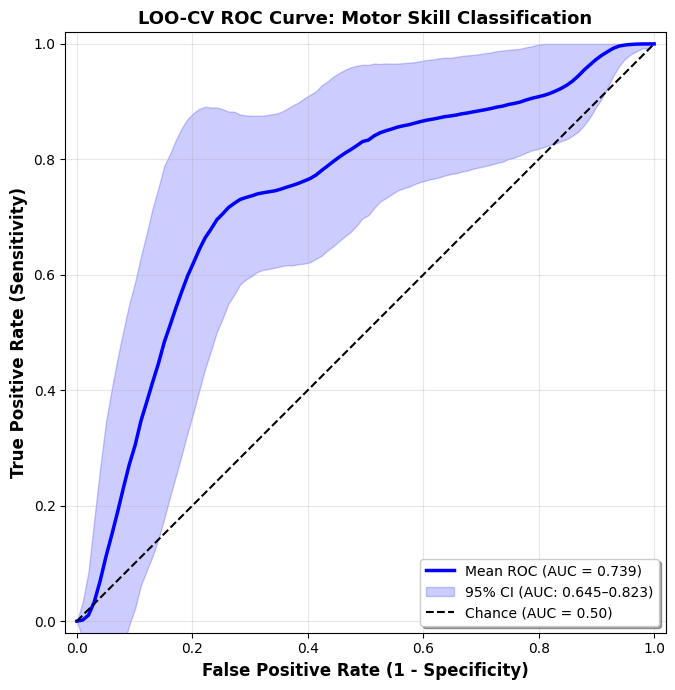


AUC: 0.739 (95% CI: [0.645, 0.823])


In [ ]:
# Bootstrap for confidence intervals
n_bootstraps = 1000
tprs = []
aucs = []
base_fpr = np.linspace(0, 1, 100)

np.random.seed(42)
for i in range(n_bootstraps):
    # Resample with replacement
    indices = resample(range(len(y)), replace=True, random_state=i)
    if len(np.unique(y.iloc[indices])) < 2:
        # Skip if bootstrap sample has only one class
        continue
    
    y_boot = y.iloc[indices]
    y_prob_boot = y_prob[indices]
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_boot, y_prob_boot)
    
    # Interpolate to common FPR axis
    tpr_interp = np.interp(base_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
    
    # Store AUC
    aucs.append(auc(fpr, tpr))

tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)

tpr_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
tpr_lower = mean_tpr - 1.96 * std_tpr

# Calculate AUC confidence interval
auc_mean = np.mean(aucs)
auc_ci_lower = np.percentile(aucs, 2.5)
auc_ci_upper = np.percentile(aucs, 97.5)

# Create plot
fig, ax = plt.subplots(figsize=(7, 7))

# Plot mean ROC curve
ax.plot(base_fpr, mean_tpr, 'b-', linewidth=2.5, 
        label=f'Mean ROC (AUC = {auc_mean:.3f})')

# Plot confidence interval
ax.fill_between(base_fpr, tpr_lower, tpr_upper, alpha=0.2, 
                color='blue', label=f'95% CI (AUC: {auc_ci_lower:.3f}–{auc_ci_upper:.3f})')

# Add chance line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Chance (AUC = 0.50)')

# Formatting
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
ax.set_title('LOO-CV ROC Curve: Motor Skill Classification', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, frameon=True, shadow=True)
ax.grid(alpha=0.3)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('plots/roc_curve_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

In [73]:
if logReg:
        
    # Prepare coefficient data
    pipe.fit(X, y)
    coefs = pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coef': coefs
    }).sort_values('coef')

    # Parse feature names for better labels
    def parse_feature(feat):
        """Extract block, task, and partner from feature name."""
        parts = feat.split('_')
        return {
            'block': parts[0],
            'task': parts[1], 
            'partner': 'Metronome' if 'Met' in feat else 'Experimenter'
        }

    coef_df['parsed'] = coef_df['feature'].apply(parse_feature)
    coef_df['block'] = coef_df['parsed'].apply(lambda x: x['block'])
    coef_df['task'] = coef_df['parsed'].apply(lambda x: x['task'])
    coef_df['partner'] = coef_df['parsed'].apply(lambda x: x['partner'])

    # Create color scheme
    colors = ['#d62728' if c > 0 else '#1f77b4' for c in coef_df['coef']]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 7))

    # Horizontal bar plot
    bars = ax.barh(range(len(coef_df)), coef_df['coef'], color=colors, alpha=0.7, 
                edgecolor='black', linewidth=0.8)

    # Create readable labels
    labels = [f"{row['block']}_{row['task']} ({row['partner'][0]})" 
            for _, row in coef_df.iterrows()]
    ax.set_yticks(range(len(coef_df)))
    ax.set_yticklabels(labels, fontsize=10)

    # Reference line at 0
    ax.axvline(x=0, color='black', linewidth=2, linestyle='-', zorder=0)

    # Highlight Task 2 + Metronome features (the contradictory pattern)
    t2_met_indices = coef_df[
        (coef_df['task'] == 'T2') & 
        (coef_df['partner'] == 'Metronome')
    ].index

    for idx in t2_met_indices:
        position = coef_df.index.get_loc(idx)
        bars[position].set_edgecolor('gold')
        bars[position].set_linewidth(3)

    # Add coefficient values on bars (for strongest features)
    for i, (idx, row) in enumerate(coef_df.iterrows()):
        if abs(row['coef']) > 0.3:  # Only label strong features
            x_pos = row['coef'] + (0.05 if row['coef'] > 0 else -0.05)
            ha = 'left' if row['coef'] > 0 else 'right'
            ax.text(x_pos, i, f"{row['coef']:.2f}", va='center', ha=ha, 
                    fontsize=9, fontweight='bold')

    # Labels and title
    ax.set_xlabel('Logistic Regression Coefficient', fontsize=13, fontweight='bold')
    ax.set_ylabel('Feature (Block_Task, Partner Type)', fontsize=13, fontweight='bold')
    ax.set_title('Feature Importance: Predicting Motor Skill Classification\n(Green vs. Amber/Red)', 
                fontsize=14, fontweight='bold', pad=20)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.7, edgecolor='black', 
            label='← Predicts Green (Lower Risk)'),
        Patch(facecolor='#d62728', alpha=0.7, edgecolor='black',
            label='Predicts Amber/Red (Higher Risk) →'),
        Patch(facecolor='white', edgecolor='gold', linewidth=3, 
            label='Task 2 + Metronome (contradictory pattern)')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10, frameon=True, shadow=True)

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_xlim(coef_df['coef'].min() - 0.2, coef_df['coef'].max() + 0.2)

    plt.tight_layout()
    plt.savefig('plots/coefficient_plot_enhanced.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary
    print("\n=== Feature Importance Summary ===")
    print(f"Total features: {len(coef_df)}")
    print(f"Features pushing toward Amber/Red (positive): {(coef_df['coef'] > 0).sum()}")
    print(f"Features pushing toward Green (negative): {(coef_df['coef'] < 0).sum()}")
    print(f"\nStrongest predictor: {coef_df.iloc[-1]['feature']} (β={coef_df.iloc[-1]['coef']:.3f})")
    print(f"Weakest predictor: {coef_df.iloc[len(coef_df)//2]['feature']} (β={coef_df.iloc[len(coef_df)//2]['coef']:.3f})")

else:
    print("\nPermutation importance (HGBC) already printed above.")


Permutation importance (HGBC) already printed above.


In [ ]:
if logReg:
    # Prepare data
    pipe.fit(X, y)
    coefs = pipe.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        'feature': feature_cols,
        'coef': coefs
    })

    # Parse features
    def parse_feature(feat):
        parts = feat.split('_')
        return {
            'block': parts[0],
            'task': parts[1], 
            'partner': 'Metronome' if 'Met' in feat else 'Experimenter'
        }

    coef_df['parsed'] = coef_df['feature'].apply(parse_feature)
    coef_df['block'] = coef_df['parsed'].apply(lambda x: x['block'])
    coef_df['task'] = coef_df['parsed'].apply(lambda x: x['task'])
    coef_df['partner'] = coef_df['parsed'].apply(lambda x: x['partner'])

    # Split by partner type
    met_df = coef_df[coef_df['partner'] == 'Metronome'].sort_values('coef').reset_index(drop=True)
    exp_df = coef_df[coef_df['partner'] == 'Experimenter'].sort_values('coef').reset_index(drop=True)

    # Create side-by-side plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

    # === LEFT PANEL: Metronome ===
    colors_met = ['#d62728' if c > 0 else '#1f77b4' for c in met_df['coef']]
    bars_met = ax1.barh(range(len(met_df)), met_df['coef'], color=colors_met, 
                        alpha=0.7, edgecolor='black', linewidth=0.8)

    # Highlight Task 2 features
    t2_indices_met = met_df[met_df['task'] == 'T2'].index
    for idx in t2_indices_met:
        bars_met[idx].set_edgecolor('gold')
        bars_met[idx].set_linewidth(3)

    labels_met = [f"{row['block']}_{row['task']}" for _, row in met_df.iterrows()]
    ax1.set_yticks(range(len(met_df)))
    ax1.set_yticklabels(labels_met, fontsize=10)
    ax1.axvline(x=0, color='black', linewidth=2)
    ax1.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax1.set_title('Participant ↔ Metronome', fontsize=13, fontweight='bold', pad=10)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')

    # Add coefficient values
    for i, (idx, row) in enumerate(met_df.iterrows()):
        if abs(row['coef']) > 0.3:
            x_pos = row['coef'] + (0.05 if row['coef'] > 0 else -0.05)
            ha = 'left' if row['coef'] > 0 else 'right'
            ax1.text(x_pos, i, f"{row['coef']:.2f}", va='center', ha=ha, 
                    fontsize=9, fontweight='bold')

    # === RIGHT PANEL: Experimenter ===
    colors_exp = ['#d62728' if c > 0 else '#1f77b4' for c in exp_df['coef']]
    bars_exp = ax2.barh(range(len(exp_df)), exp_df['coef'], color=colors_exp, 
                        alpha=0.7, edgecolor='black', linewidth=0.8)

    labels_exp = [f"{row['block']}_{row['task']}" for _, row in exp_df.iterrows()]
    ax2.set_yticks(range(len(exp_df)))
    ax2.set_yticklabels(labels_exp, fontsize=10)
    ax2.axvline(x=0, color='black', linewidth=2)
    ax2.set_xlabel('Coefficient', fontsize=12, fontweight='bold')
    ax2.set_title('Participant ↔ Experimenter', fontsize=13, fontweight='bold', pad=10)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')

    # Add coefficient values
    for i, (idx, row) in enumerate(exp_df.iterrows()):
        if abs(row['coef']) > 0.3:
            x_pos = row['coef'] + (0.05 if row['coef'] > 0 else -0.05)
            ha = 'left' if row['coef'] > 0 else 'right'
            ax2.text(x_pos, i, f"{row['coef']:.2f}", va='center', ha=ha, 
                    fontsize=9, fontweight='bold')

    # Overall title and legend
    fig.suptitle('Feature Importance by Partner Type\n(Predicting Motor Skill Classification)', 
                fontsize=14, fontweight='bold', y=0.98)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', alpha=0.7, edgecolor='black', 
            label='← Predicts Green'),
        Patch(facecolor='#d62728', alpha=0.7, edgecolor='black',
            label='Predicts Amber/Red →'),
        Patch(facecolor='white', edgecolor='gold', linewidth=3, 
            label='Task 2 (highlighted)')
    ]
    fig.legend(handles=legend_elements, loc='upper center', ncol=3, 
            fontsize=10, frameon=True, bbox_to_anchor=(0.5, 0.95))

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig('plots/coefficient_plot_by_partner.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Summary statistics
    print("\n=== Metronome Features ===")
    print(f"Total: {len(met_df)}")
    print(f"Positive (→ Amber/Red): {(met_df['coef'] > 0).sum()}")
    print(f"Negative (→ Green): {(met_df['coef'] < 0).sum()}")
    print(f"Strongest: {met_df.iloc[-1]['feature']} (β={met_df.iloc[-1]['coef']:.3f})")

    print("\n=== Experimenter Features ===")
    print(f"Total: {len(exp_df)}")
    print(f"Positive (→ Amber/Red): {(exp_df['coef'] > 0).sum()}")
    print(f"Negative (→ Green): {(exp_df['coef'] < 0).sum()}")
    if len(exp_df) > 0:
        strongest_exp_feat = exp_df.iloc[-1]['feature']
        strongest_exp_coef = exp_df.iloc[-1]['coef']
        print(f"Strongest: {strongest_exp_feat} (β={strongest_exp_coef:.3f})")
    else:
        print("Strongest: N/A")

else:
    print("\nPermutation importance (HGBC) already printed above.")


Permutation importance (HGBC) already printed above.


### Examination of Misclassified Cases

Error analysis reveals critical patterns in model failures, particularly among at-risk children:

#### False Negatives (Missed At-Risk Cases)
False negatives—at-risk children incorrectly classified as typical—represent the most clinically significant errors, as they result in missed intervention opportunities.

**Key Finding**: False negatives were disproportionately comprised of **Amber-classified children** (44.4% of FNs) compared to their representation in the overall at-risk sample (23.3%), suggesting the model is more sensitive to severe motor impairment (Red) than borderline cases. Specifically:
- **Red sensitivity**: 78.3% (18 of 23 Red cases correctly identified)
- **Amber sensitivity**: 42.9% (only 3 of 7 Amber cases correctly identified)

This indicates the model may require stronger coordination signals to flag borderline cases, potentially missing children with emerging or subtle motor difficulties.

### Subsequent Analysis
The following cells examine false negatives and false positives in detail, stratified by classification group (Green vs. Amber/Red), to identify demographic and neurotype-related patterns that might explain misclassification.

In [ ]:
# Collate predictions back onto model_df
results_df = model_df[["ppt", "child_age_years", "neurotype",  "data_alignment", "data_violations", "mabc_interpretation", "mabc_binary"]].copy()
results_df["y_prob"] = y_prob
results_df["y_pred"] = y_pred

results_df["pred_label"] = results_df["y_pred"].map({0: "Green", 1: "Amber/Red"})
results_df["true_label"] = results_df["mabc_binary"].map({0: "Green", 1: "Amber/Red"})

# Error type
results_df["error_type"] = np.where(
    results_df["y_pred"] == results_df["mabc_binary"],
    "Correct",
    np.where(results_df["mabc_binary"] == 1, "Amber/Red→Green (FN)", "Green→Amber/Red (FP)")
)

print("Counts by error type:")
print(results_df["error_type"].value_counts())
print()

# Print misclassified participants
misclassified_df = results_df[results_df["error_type"] != "Correct"].copy()

## Sort by confidence (how far from 0.5)
misclassified_df["confidence_dist"] = (misclassified_df["y_prob"] - 0.5).abs()
misclassified_df = misclassified_df.sort_values(["error_type", "confidence_dist"], ascending=[True, False])

print("Misclassified children (sorted by confidence):")
print(misclassified_df[[
    "ppt", "child_age_years", "neurotype",
    "data_alignment", "data_violations",
    "mabc_interpretation", "true_label",
    "pred_label", "y_prob", "confidence_dist", "error_type"
]].to_string(index=False))
print()

# Determine whether FN cases more likely to be Amber than Red
fn_df = results_df[results_df["error_type"] == "Amber/Red→Green (FN)"].copy()

print(f"False negatives (Amber/Red misclassified as Green): n = {len(fn_df)}")
print("Breakdown of MABC categories within false negatives:")
print(fn_df["mabc_interpretation"].value_counts())
print()

## Compare to the overall at-risk composition
at_risk_df = results_df[results_df["mabc_binary"] == 1].copy()
print("Overall Amber/Red composition:")
print(at_risk_df["mabc_interpretation"].value_counts())
print()

# Proportion table (Amber vs Red within FN vs within all Amber/Red participants)
def prop(series):
    return (series.value_counts(normalize=True) * 100).round(1)

print("Percent composition within FN:")
print(prop(fn_df["mabc_interpretation"]))
print("\nPercent composition within all Amber/Red participants:")
print(prop(at_risk_df["mabc_interpretation"]))


Counts by error type:
error_type
Correct                 94
Green→Amber/Red (FP)    20
Amber/Red→Green (FN)    12
Name: count, dtype: int64
Misclassified children (sorted by confidence):
 ppt  child_age_years neurotype data_alignment data_violations mabc_interpretation true_label pred_label   y_prob  confidence_dist           error_type
  31                8        TD     Misaligned            MABC               Amber  Amber/Red      Green 0.004213         0.495787 Amber/Red→Green (FN)
  84                9       ASD        Aligned             NaN                 Red  Amber/Red      Green 0.004475         0.495525 Amber/Red→Green (FN)
 101               10       ASD        Aligned             NaN                 Red  Amber/Red      Green 0.004739         0.495261 Amber/Red→Green (FN)
  49               10       ASD        Aligned             NaN               Amber  Amber/Red      Green 0.007412         0.492588 Amber/Red→Green (FN)
  54               14       ASD        Aligned       

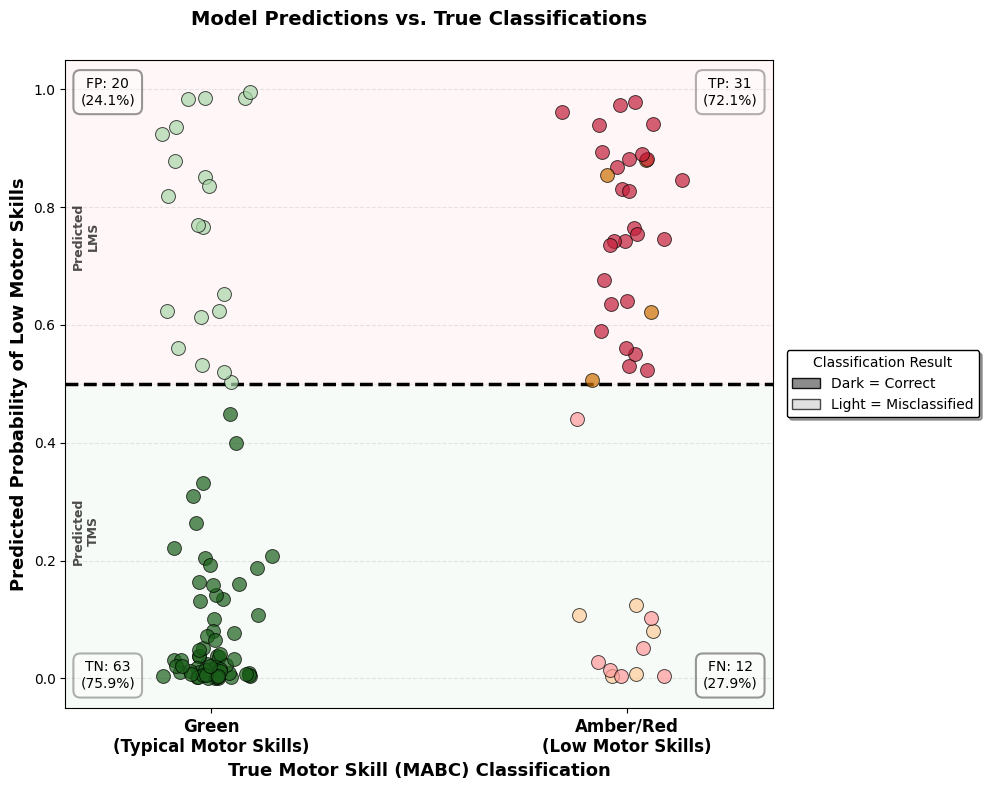


=== Prediction Summary ===
Total cases: 126

True Negatives (Green correctly classified): 63 (75.9% of Green)
False Positives (Green misclassified): 20 (24.1% of Green)
True Positives (Low Motor Skills correctly classified): 31 (72.1% of Low Motor Skills)
False Negatives (Low Motor Skills misclassified): 12 (27.9% of Low Motor Skills)

=== False Negative Details ===
Mean predicted probability: 0.081 (SD=0.122)
Range: 0.004 to 0.440
Breakdown by MABC category:
mabc_interpretation
Red      7
Amber    5
Name: count, dtype: int64

=== False Positive Details ===
Mean predicted probability: 0.768 (SD=0.175)
Range: 0.503 to 0.996


In [76]:
# Add jitter for visibility
np.random.seed(42)
results_df['jitter_x'] = results_df['true_label'].map({'Green': 0, 'Amber/Red': 1}) + \
                         np.random.normal(0, 0.06, len(results_df))

# Create color mapping: true classification (including Amber vs Red) + correction status
# Dark colors for correct, light colors for incorrect
color_map = {
    ('Green', 'Correct'): '#1a5f1a',                    # Dark green
    ('Green', 'Green→Amber/Red (FP)'): '#a8d5a8',       # Light green
    ('Amber', 'Correct'): '#cc7000',                    # Dark amber/orange
    ('Amber', 'Amber/Red→Green (FN)'): '#ffcc99',       # Light amber/orange
    ('Red', 'Correct'): '#c41e3a',                      # Dark red
    ('Red', 'Amber/Red→Green (FN)'): '#ff9999'          # Light red
}

# Assign colors based on MABC interpretation and error type
results_df['point_color'] = results_df.apply(
    lambda row: color_map[(row['mabc_interpretation'], row['error_type'])], 
    axis=1
)

# Create figure with narrower width to bring categories closer
fig, ax = plt.subplots(figsize=(10, 8))

# Plot all points with their assigned colors
for idx, row in results_df.iterrows():
    ax.scatter(row['jitter_x'], row['y_prob'], 
               color=row['point_color'], s=100, alpha=0.7, 
               edgecolors='black', linewidth=0.7, zorder=3)

# Decision threshold
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=2.5, 
           label='Decision Threshold (0.5)', zorder=2)

# Calculate sample sizes for percentage calculations
green_n = len(results_df[results_df['true_label'] == 'Green'])
amber_n = len(results_df[results_df['true_label'] == 'Amber/Red'])

# Calculate counts for all four categories
tn_count = len(results_df[(results_df['true_label'] == 'Green') & (results_df['error_type'] == 'Correct')])
fp_count = len(results_df[(results_df['true_label'] == 'Green') & (results_df['error_type'] == 'Green→Amber/Red (FP)')])
fn_count = len(results_df[(results_df['true_label'] == 'Amber/Red') & (results_df['error_type'] == 'Amber/Red→Green (FN)')])
tp_count = len(results_df[(results_df['true_label'] == 'Amber/Red') & (results_df['error_type'] == 'Correct')])

# Improved annotation boxes with better positioning
# True Negatives box (bottom left) - positioned closer to plot
ax.text(0.06, 0.05, f'TN: {tn_count}\n({tn_count/green_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.3, edgecolor='black', linewidth=1.5))

# False Positives box (top left) - positioned closer to plot
ax.text(0.06, 0.95, f'FP: {fp_count}\n({fp_count/green_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, va='center', ha='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.4, edgecolor='black', linewidth=1.5))

# True Positives box (top right) - positioned closer to plot
ax.text(0.94, 0.95, f'TP: {tp_count}\n({tp_count/amber_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.3, edgecolor='black', linewidth=1.5))

# False Negatives box (bottom right) - positioned closer to plot
ax.text(0.94, 0.05, f'FN: {fn_count}\n({fn_count/amber_n*100:.1f}%)', 
        transform=ax.transAxes, fontsize=10, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffffff', alpha=0.4, edgecolor='black', linewidth=1.5))

# Formatting
ax.set_xticks([0, 1])
ax.set_xticklabels(['Green\n(Typical Motor Skills)', 'Amber/Red\n(Low Motor Skills)'], 
                   fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Probability of Low Motor Skills', fontsize=13, fontweight='bold')
ax.set_xlabel('True Motor Skill (MABC) Classification', fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-0.35, 1.35)  # Keep wider to accommodate boxes and labels
ax.set_title('Model Predictions vs. True Classifications', 
             fontsize=14, fontweight='bold', pad=25)

# Grid
ax.grid(alpha=0.3, axis='y', linestyle='--', linewidth=0.8, zorder=1)

# Add shaded regions to show classification zones (lighter for less visual clutter)
ax.axhspan(0.5, 1.05, alpha=0.03, color='red', zorder=0)
ax.axhspan(-0.05, 0.5, alpha=0.03, color='green', zorder=0)

# Add zone labels (positioned outside to avoid data overlap)
ax.text(-0.30, 0.25, 'Predicted\nTMS', fontsize=9, ha='center', 
        va='center', color='black', fontweight='bold', alpha=0.7, 
        rotation=90)
ax.text(-0.30, 0.75, 'Predicted\nLMS', fontsize=9, ha='center', 
        va='center', color='black', fontweight='bold', alpha=0.7,
        rotation=90)

# Simplified legend showing just the pattern
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', edgecolor='black', alpha=0.9,
          label='Dark = Correct'),
    Patch(facecolor='lightgray', edgecolor='black', alpha=0.7,
          label='Light = Misclassified')
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.01, 0.5), 
          fontsize=10, frameon=True, shadow=True, 
          title='Classification Result', title_fontsize=10,
          edgecolor='black', fancybox=True)

plt.tight_layout()
plt.savefig('plots/prediction_scatter_improved.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n=== Prediction Summary ===")
print(f"Total cases: {len(results_df)}")
print(f"\nTrue Negatives (Green correctly classified): {tn_count} ({tn_count/green_n*100:.1f}% of Green)")
print(f"False Positives (Green misclassified): {fp_count} ({fp_count/green_n*100:.1f}% of Green)")
print(f"True Positives (Low Motor Skills correctly classified): {tp_count} ({tp_count/amber_n*100:.1f}% of Low Motor Skills)")
print(f"False Negatives (Low Motor Skills misclassified): {fn_count} ({fn_count/amber_n*100:.1f}% of Low Motor Skills)")

# Detailed error analysis
print("\n=== False Negative Details ===")
fn_df = results_df[results_df['error_type'] == 'Amber/Red→Green (FN)'].copy()
print(f"Mean predicted probability: {fn_df['y_prob'].mean():.3f} (SD={fn_df['y_prob'].std():.3f})")
print(f"Range: {fn_df['y_prob'].min():.3f} to {fn_df['y_prob'].max():.3f}")
print(f"Breakdown by MABC category:")
print(fn_df['mabc_interpretation'].value_counts())

print("\n=== False Positive Details ===")
fp_df = results_df[results_df['error_type'] == 'Green→Amber/Red (FP)'].copy()
print(f"Mean predicted probability: {fp_df['y_prob'].mean():.3f} (SD={fp_df['y_prob'].std():.3f})")
print(f"Range: {fp_df['y_prob'].min():.3f} to {fp_df['y_prob'].max():.3f}")

## Green-only misclassification diagnostics

- Within the Green group, misclassified children were slightly younger on average (M = 9.21 years, SD = 2.51) than correctly classified children (M = 9.66 years, SD = 2.30), though considerable overlap existed. Notably, 32% (6/19) of false positives were 7-year-olds compared to 11% (6/53) of correctly classified Green children.

- Green children who were misclassified as at-risk showed a higher proportion of autistic participants (41%, 7/17 with known neurotype) compared to correctly classified Green children (29%, 15/51), suggesting that coordination dynamics may reflect trait-level differences not captured by categorical motor-function classification. These descriptive patterns should be interpreted cautiously given small cell sizes.

In [77]:
# Focus on Green children only
green_df = results_df[results_df["true_label"] == "Green"].copy()

# Add a flag for misclassification
green_df["misclassified"] = np.where(
    green_df["pred_label"] == "Amber/Red",
    "Misclassified",
    "Correct"
)

print("Green group counts:")
print(green_df["misclassified"].value_counts())
print()

# Compare ages of misclassified vs correctly classified Green children
age_summary = (
    green_df
    .groupby("misclassified")["child_age_years"]
    .agg(["count", "mean", "std", "median"])
)

print("Age summary (Green group):")
print(age_summary)
print()

# Optional: show individual ages
print("Ages of misclassified Green children:")
print(
    green_df.loc[green_df["misclassified"] == "Misclassified",
                 ["ppt", "child_age_years"]]
    .sort_values("child_age_years")
    .to_string(index=False)
)
print()

# Compare neurotype distribution of misclassified vs correctly classified Green children
neurotype_table = (
    green_df
    .groupby(["misclassified", "neurotype"])
    .size()
    .unstack(fill_value=0)
)

print("Neurotype counts (Green group):")
print(neurotype_table)
print()

# Convert to percentages within misclassification status
neurotype_prop = neurotype_table.div(neurotype_table.sum(axis=1), axis=0) * 100

print("Neurotype percentages within Green group:")
print(neurotype_prop.round(1))
print()


Green group counts:
misclassified
Correct          63
Misclassified    20
Name: count, dtype: int64

Age summary (Green group):
               count      mean       std  median
misclassified                                   
Correct           63  9.539683  2.227579     9.0
Misclassified     20  8.750000  2.403397     7.5

Ages of misclassified Green children:
 ppt  child_age_years
  15                7
  38                7
  24                7
  22                7
  77                7
  85                7
  39                7
  91                7
  96                7
 104                7
  60                8
   6                8
  67                9
  75               10
  10               10
  19               10
  50               11
  79               11
 112               12
  20               16

Neurotype counts (Green group):
neurotype      ASD  DCD  TD
misclassified              
Correct         16    2  44
Misclassified    7    1   9

Neurotype percentages within 

## Amber/Red-only misclassification diagnostics

- Within the Amber/Red group, misclassified children were slightly older on average (M = 9.89 years, SD = 2.15) than correctly classified children (M = 9.29 years, SD = 1.98), though both groups had the same median age (9.0 years). False negatives were disproportionately Amber-classified children (44%, 4/9) compared to their representation in the overall at-risk sample (23%, 7/30), indicating the model was more sensitive to severe motor impairment (Red: 78% sensitivity, 18/23) than borderline cases (Amber: 43% sensitivity, 3/7).

- Among at-risk children with known neurotype, false negatives comprised 26% (5/19) of autistic participants, 29% (2/7) of DCD participants, and 67% (2/3) of typically developing children. Notably, both of the typically developing children who were missed came into the study without reported movement difficulties, and scored 'Amber' on the MABC. The third (correctly identified) child, also came into the study with no reported movement difficulties, but scored 'Red' on the MABC during testing.

In [78]:
# Focus on Amber/Red children only
atrisk_df = results_df[results_df["true_label"] == "Amber/Red"].copy()

# Flag misclassification
atrisk_df["misclassified"] = np.where(
    atrisk_df["pred_label"] == "Green",
    "Misclassified",
    "Correct"
)

print("Amber/Red group counts:")
print(atrisk_df["misclassified"].value_counts())
print()

# Compare ages of misclassified vs correctly classified Amber/Red children
age_summary_ar = (
    atrisk_df
    .groupby("misclassified")["child_age_years"]
    .agg(["count", "mean", "std", "median"])
)

print("Age summary (Amber/Red group):")
print(age_summary_ar)
print()

# Show individual ages for misclassified Amber/Red children
print("Ages of misclassified Amber/Red children:")
print(
    atrisk_df.loc[atrisk_df["misclassified"] == "Misclassified",
                  ["ppt", "child_age_years", "mabc_interpretation"]]
    .sort_values("child_age_years")
    .to_string(index=False)
)
print()

# Compare neurotype distribution of misclassified vs correctly classified Amber/Red children
neurotype_table_ar = (
    atrisk_df
    .groupby(["misclassified", "neurotype"])
    .size()
    .unstack(fill_value=0)
)

print("Neurotype counts (Amber/Red group):")
print(neurotype_table_ar)
print()

# Percentages within misclassification status
neurotype_prop_ar = neurotype_table_ar.div(neurotype_table_ar.sum(axis=1), axis=0) * 100

print("Neurotype percentages within Amber/Red group:")
print(neurotype_prop_ar.round(1))
print()


Amber/Red group counts:
misclassified
Correct          31
Misclassified    12
Name: count, dtype: int64

Age summary (Amber/Red group):
               count       mean       std  median
misclassified                                    
Correct           31   9.161290  2.177105     9.0
Misclassified     12  10.083333  1.928652     9.5

Ages of misclassified Amber/Red children:
 ppt  child_age_years mabc_interpretation
  28                8               Amber
  31                8               Amber
  14                9               Amber
   3                9                 Red
  48                9               Amber
  84                9                 Red
  81               10                 Red
  49               10               Amber
 101               10                 Red
  61               12                 Red
  27               13                 Red
  54               14                 Red

Neurotype counts (Amber/Red group):
neurotype      ASD  DCD  TD
misclassif